In [2]:
##import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline 

Text(0, 0.5, 'Y dataset')

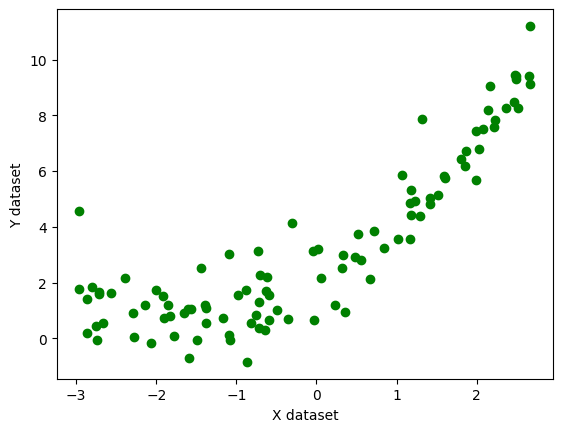

In [3]:
X = 6 * np.random.rand(100, 1) - 3
y =0.5 * X**2 + 1.5*X + 2 + np.random.randn(100, 1)
# quadratic equation used- y=0.5x^2+1.5x+2+outliers
plt.scatter(X,y,color='g')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')

In [4]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [5]:
## Lets implement Simple Linear Regression
from sklearn.linear_model import LinearRegression
regression_1=LinearRegression()

In [6]:
regression_1.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
from sklearn.metrics import r2_score
score=r2_score(y_test,regression_1.predict(X_test))
print(score)

0.6143923392745589


Text(0, 0.5, 'Y')

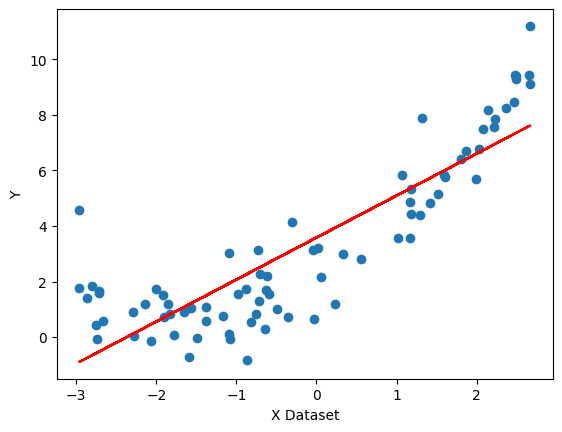

In [8]:
## Lets visualize this model
plt.plot(X_train,regression_1.predict(X_train),color='r')
plt.scatter(X_train,y_train)
plt.xlabel("X Dataset")
plt.ylabel("Y")


In [9]:
#LEts apply polynomial transformation
from sklearn.preprocessing import PolynomialFeatures

In [10]:
poly=PolynomialFeatures(degree=2,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [11]:
X_train_poly

array([[ 1.00000000e+00,  2.21631647e+00,  4.91205870e+00],
       [ 1.00000000e+00,  1.18251139e+00,  1.39833319e+00],
       [ 1.00000000e+00,  1.51696986e+00,  2.30119756e+00],
       [ 1.00000000e+00, -1.08564861e+00,  1.17863290e+00],
       [ 1.00000000e+00, -6.21070732e-01,  3.85728854e-01],
       [ 1.00000000e+00,  2.30906370e-01,  5.33177516e-02],
       [ 1.00000000e+00, -1.92038999e+00,  3.68789771e+00],
       [ 1.00000000e+00,  1.06305677e+00,  1.13008971e+00],
       [ 1.00000000e+00, -7.01449005e-01,  4.92030706e-01],
       [ 1.00000000e+00, -2.14492139e+00,  4.60068775e+00],
       [ 1.00000000e+00, -2.95881029e+00,  8.75455835e+00],
       [ 1.00000000e+00, -1.07421215e+00,  1.15393175e+00],
       [ 1.00000000e+00, -1.49604129e+00,  2.23813955e+00],
       [ 1.00000000e+00,  1.61147417e+00,  2.59684901e+00],
       [ 1.00000000e+00, -1.65112618e+00,  2.72621767e+00],
       [ 1.00000000e+00,  1.16353014e+00,  1.35380238e+00],
       [ 1.00000000e+00,  1.75473358e-02

In [12]:
X_test_poly

array([[ 1.        ,  0.84962508,  0.72186277],
       [ 1.        ,  0.66978166,  0.44860747],
       [ 1.        ,  0.48146896,  0.23181236],
       [ 1.        ,  0.51821519,  0.26854698],
       [ 1.        ,  2.16925456,  4.70566535],
       [ 1.        , -1.38992551,  1.93189292],
       [ 1.        ,  0.71981967,  0.51814035],
       [ 1.        , -2.86607777,  8.21440177],
       [ 1.        ,  0.32526457,  0.10579704],
       [ 1.        ,  0.3604597 ,  0.1299312 ],
       [ 1.        , -0.59516349,  0.35421958],
       [ 1.        ,  1.9974459 ,  3.98979013],
       [ 1.        , -1.4363749 ,  2.06317284],
       [ 1.        ,  1.86061382,  3.46188379],
       [ 1.        ,  2.52088814,  6.35487699],
       [ 1.        , -0.72064143,  0.51932406],
       [ 1.        ,  1.42345479,  2.02622353],
       [ 1.        , -2.3841002 ,  5.68393374],
       [ 1.        ,  1.23617146,  1.52811987],
       [ 1.        , -2.56317692,  6.56987595]])

In [13]:

from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score=r2_score(y_test,y_pred)
print(score)

0.8788818623437951


In [14]:
print(regression.coef_)

[[0.         1.58085828 0.47650252]]


In [15]:
print(regression.intercept_)

[2.13282558]


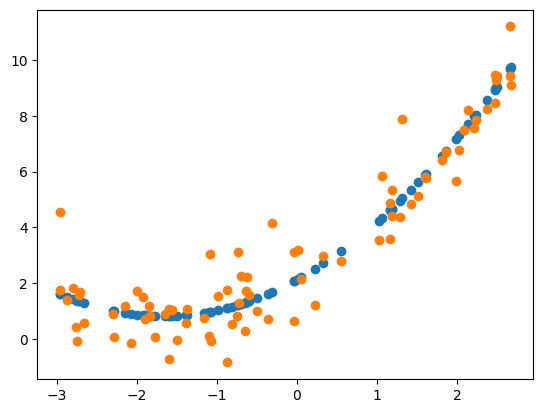

In [16]:
plt.scatter(X_train,regression.predict(X_train_poly))
plt.scatter(X_train,y_train)

In [17]:
poly=PolynomialFeatures(degree=3,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [18]:
X_train_poly

array([[ 1.00000000e+00,  2.21631647e+00,  4.91205870e+00,
         1.08866766e+01],
       [ 1.00000000e+00,  1.18251139e+00,  1.39833319e+00,
         1.65354493e+00],
       [ 1.00000000e+00,  1.51696986e+00,  2.30119756e+00,
         3.49084734e+00],
       [ 1.00000000e+00, -1.08564861e+00,  1.17863290e+00,
        -1.27958117e+00],
       [ 1.00000000e+00, -6.21070732e-01,  3.85728854e-01,
        -2.39564902e-01],
       [ 1.00000000e+00,  2.30906370e-01,  5.33177516e-02,
         1.23114085e-02],
       [ 1.00000000e+00, -1.92038999e+00,  3.68789771e+00,
        -7.08220183e+00],
       [ 1.00000000e+00,  1.06305677e+00,  1.13008971e+00,
         1.20134952e+00],
       [ 1.00000000e+00, -7.01449005e-01,  4.92030706e-01,
        -3.45134449e-01],
       [ 1.00000000e+00, -2.14492139e+00,  4.60068775e+00,
        -9.86811354e+00],
       [ 1.00000000e+00, -2.95881029e+00,  8.75455835e+00,
        -2.59030774e+01],
       [ 1.00000000e+00, -1.07421215e+00,  1.15393175e+00,
      

In [19]:

from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score=r2_score(y_test,y_pred)
print(score)

0.8733579418169831


In [20]:
#3 Prediction of new data set
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

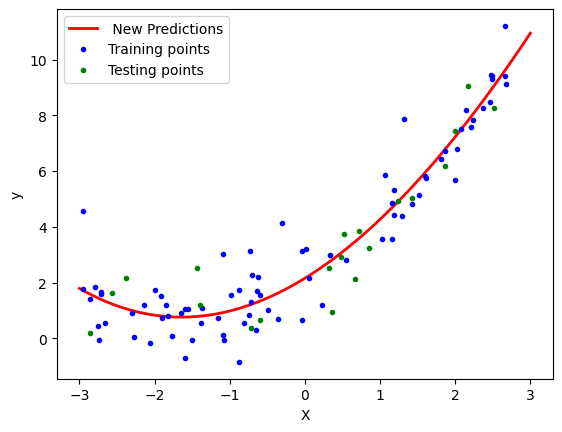

In [ ]:
y_new = regression.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth=2, label=" New Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Pipeline Concepts 

In [22]:
from sklearn.pipeline import Pipeline

In [23]:
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    
    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(X_train,y_train) ## ploynomial and fit of linear reression
    y_pred_new=poly_regression.predict(X_new)
    #plotting prediction line
    plt.plot(X_new, y_pred_new,'r', label="Degree " + str(degree), linewidth=2)
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4, 0, 10])
    plt.show()
    

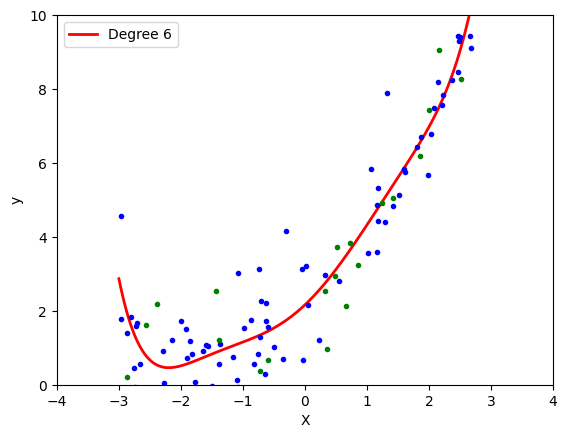

In [24]:
poly_regression(6)